In [ ]:
from discodj import DiscoDJ
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
from matplotlib.colors import SymLogNorm
from discodj import DiscoDJ

In [2]:
dj = DiscoDJ(dim=3, res=256, boxsize=100.0)
dj = dj.with_timetables()
dj = dj.with_linear_ps()
dj = dj.with_ics()
dj = dj.with_lpt(n_order=1)

X, P, a = dj.run_nbody(a_ini=0.02, a_end=1.0, n_steps=10, res_pm=512, stepper="bullfrog")

print("Simulation complete!")
print("Positions shape:", X.shape)

Simulation complete!
Positions shape: (256, 256, 256, 3)


## 3D Map

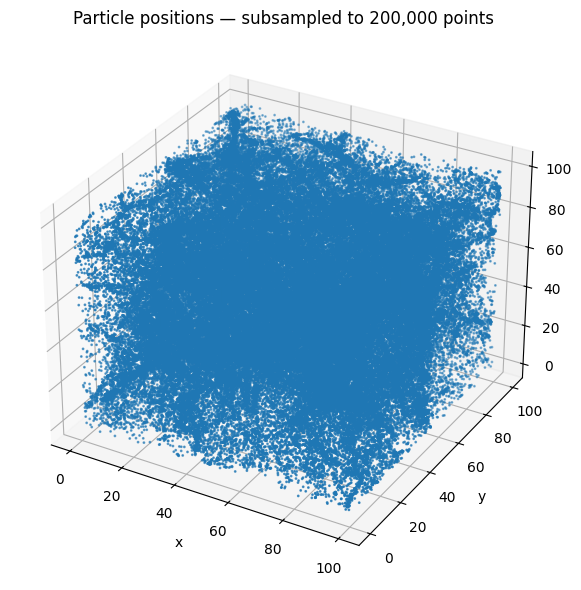

In [3]:
# Plot particle positions with optional snapshot/time selection

snapshot_index = -1  # Use -1 for the most recent snapshot when X has a time axis
arr = X
if arr is None:
    raise NameError("X not found — run the simulation cell first.")

# If X stores multiple snapshots, select the requested one
if arr.ndim >= 4 and arr.shape[-1] in (2, 3) and arr.shape[0] != arr.shape[1]:
    arr = arr[snapshot_index]

# Handle tensor/grid positions by flattening everything but the coordinate axis
if arr.ndim >= 2 and arr.shape[-1] in (2, 3):
    pos = arr.reshape(-1, arr.shape[-1])
else:
    raise ValueError(f"Unexpected X shape: {arr.shape}")

# Subsample if there are too many points to plot
max_points = 200_000
n_points = pos.shape[0]
if n_points > max_points:
    rng = np.random.default_rng(0)
    idx = rng.choice(n_points, size=max_points, replace=False)
    pos = pos[idx]
    sampled = True
else:
    sampled = False

# Plot 3D or 2D depending on coordinate dimension
if pos.shape[1] == 3:
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pos[:,0], pos[:,1], pos[:,2], s=1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
else:
    plt.figure(figsize=(6,6))
    plt.scatter(pos[:,0], pos[:,1], s=1)
    plt.xlabel('x')
    plt.ylabel('y')

title = 'Particle positions'
if sampled:
    title += f' — subsampled to {pos.shape[0]:,} points'
plt.title(title)
plt.tight_layout()
plt.show()


## 2D Map

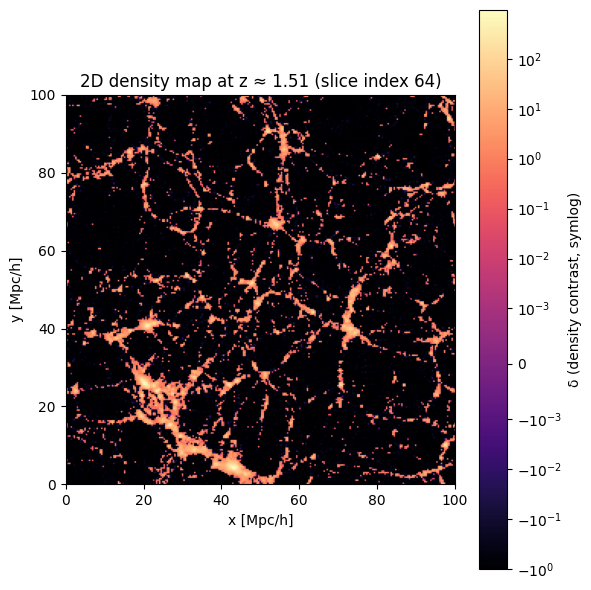

In [4]:
# 2D density map for a chosen redshift-like slice along the z-axis
# User inputs
target_redshift = 1.5       # Desired redshift to visualize (adjust as needed)
z_range = (0.0, 6.0)        # Mapping of the box's z-axis to redshift values (near, far)
slice_axis = 2              # Treat the third spatial axis as the line-of-sight/redshift axis

if 'dj' not in globals():
    raise NameError("dj is not defined — run the simulation setup cell first.")
if 'X' not in globals():
    raise NameError("X is not defined — run the simulation cell first.")

positions = np.asarray(X)
if positions.ndim >= 5 and positions.shape[-1] == dj.dim:
    positions = positions[-1]  # Default to the latest snapshot if time axis is present
if positions.shape[-1] != dj.dim:
    raise ValueError(f"Unexpected position shape: {positions.shape}")

res = positions.shape[0]
if not all(positions.shape[d] == res for d in range(dj.dim)):
    raise ValueError("Expected a cubic mesh of particle positions.")

# Map the requested redshift to a slice index along the chosen axis
z_axis = np.linspace(z_range[0], z_range[1], res)
slice_index = int(np.abs(z_axis - target_redshift).argmin())
fixed_inds = [None] * dj.dim
fixed_inds[slice_axis] = slice_index

# Compute the density slice in the chosen plane using DiscoDJ's helper
pos_flat = positions.reshape(-1, dj.dim)
delta_slice = dj.get_delta_from_pos_on_slice_or_skewer(
    pos_flat,
    fixed_inds=fixed_inds,
    res=res,
    worder=2,
    deconvolve=False,
    n_resample=1,
    antialias=False,
    try_to_jit=False,
)
delta_slice = np.asarray(delta_slice)

fig, ax = plt.subplots(figsize=(6, 6))
extent = (0, dj.boxsize, 0, dj.boxsize)
# Use symmetric log normalization to show both negative and positive contrasts
norm = SymLogNorm(linthresh=1e-3, linscale=1.0, vmin=delta_slice.min(), vmax=delta_slice.max())
im = ax.imshow(delta_slice, origin='lower', cmap='magma', extent=extent, norm=norm)
cbar = fig.colorbar(im, ax=ax, label='δ (density contrast, symlog)')
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
ax.set_title(f"2D density map at z ≈ {z_axis[slice_index]:.2f} (slice index {slice_index})")
plt.tight_layout()
plt.show()
